# Importing Libraries

In [1]:
import os
import json
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB1, InceptionResNetV2, Xception, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.regularizers import l2

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from keras import utils
from keras.models import Model
from keras.callbacks import ModelCheckpoint


2026-01-11 17:12:47.862980: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768151568.096422      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768151568.166106      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768151568.725615      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768151568.725678      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768151568.725681      24 computation_placer.cc:177] computation placer alr

# Seeding

In [2]:
seed = 18114
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS']= '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    random.seed(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    
seed_everything(seed)

# Constants and configurations

In [3]:
train_folder = '/kaggle/input/driver-inattention-detection-dataset/train'
test_folder = '/kaggle/input/driver-inattention-detection-dataset/test'
valid_folder = '/kaggle/input/driver-inattention-detection-dataset/valid'

# Recommended with EfficientNetB1
IMG_SIZE = 224
TARGET_SIZE = (IMG_SIZE, IMG_SIZE)
NUM_CLASSES = 6

strategy = tf.distribute.MirroredStrategy()
BATCH_SIZE_PER_REPLICA = 64
BATCH_SIZE = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync
WARMUP_EPOCHS = 10
EPOCHS = 40
LR = 0.001

checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_{epoch}.weights.h5")

print('Devices Available: {}'.format(strategy.num_replicas_in_sync))

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Devices Available: 2


I0000 00:00:1768151582.456408      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768151582.460316      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# PreProcessing Dataset

In [4]:
def read_annotations(file_path):
    annotations = []
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            image_name = parts[0]
            try:
                bbox = list(map(int, parts[1].split(',')))
                if len(bbox) != 5:
                    continue
                annotations.append([image_name] + bbox)
            except ValueError:
                continue
    return pd.DataFrame(annotations, columns=['image_name', 'x_min', 'y_min', 'x_max', 'y_max', 'class_id'])

def preprocess_image(image_path, target_size):
    image = cv2.imread(image_path)
    if image is None:
        return None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, target_size)
    image = preprocess_input(image)
    return image

# Hàm mã hóa one-hot cho nhãn
def one_hot_encode_labels(labels, num_classes):
    encoder = OneHotEncoder(sparse_output=False)
    labels = np.array(labels).reshape(-1, 1)
    one_hot_labels = encoder.fit_transform(labels)
    return one_hot_labels

def preprocess_dataset(annotations, folder_path, num_classes):
    images = []
    labels = []
    for _, row in annotations.iterrows():
        image_path = os.path.join(folder_path, row['image_name'])
        image = preprocess_image(image_path, TARGET_SIZE)
        if image is None:
            continue
        images.append(image)
        labels.append(row['class_id'])
    images = np.array(images)
    one_hot_labels = one_hot_encode_labels(labels, num_classes)
    return images, one_hot_labels
    

train_annotations = read_annotations(train_folder + '/_annotations.txt')
test_annotations = read_annotations(test_folder + '/_annotations.txt')
valid_annotations = read_annotations(valid_folder + '/_annotations.txt')


train_images, train_labels = preprocess_dataset(train_annotations, train_folder, NUM_CLASSES)
test_images, test_labels = preprocess_dataset(test_annotations, test_folder, NUM_CLASSES)
valid_images, valid_labels = preprocess_dataset(valid_annotations, valid_folder, NUM_CLASSES)

In [5]:
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)

print("Valid images shape:", valid_images.shape)
print("Valid labels shape:", valid_labels.shape)

print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Train images shape: (11948, 224, 224, 3)
Train labels shape: (11948, 6)
Valid images shape: (1922, 224, 224, 3)
Valid labels shape: (1922, 6)
Test images shape: (985, 224, 224, 3)
Test labels shape: (985, 6)


In [6]:
(x_train, y_train), (x_val, y_val) = (train_images, train_labels), (valid_images, valid_labels)

In [7]:
class_weights = compute_class_weight('balanced', 
                                    classes=np.unique(train_annotations['class_id']), 
                                    y=train_annotations['class_id'])
class_weight_dict = dict(enumerate(class_weights))

# Parallel Dataset creation

In [8]:
def create_datasets(x_train, y_train, x_val, y_val, batch_size):
    train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_dataset = train_dataset.shuffle(len(x_train), seed=seed)
    train_dataset = train_dataset.batch(batch_size)
    train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
    
    val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
    val_dataset = val_dataset.batch(batch_size)
    val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)
    
    return train_dataset, val_dataset

# Building the model

In [9]:
#NOTE: we can add l1,l2 regulizers, and may start with 0.01 or similar

with strategy.scope():

    train_dataset, val_dataset = create_datasets(
        x_train, y_train, x_val, y_val, BATCH_SIZE
    )

    #Optimizer definition
    optimizer = optimizer=Adam(learning_rate=LR)
    
    #Callbacks definition
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    checkpoint = ModelCheckpoint(filepath=checkpoint_prefix,
                                save_best_only=True,
                                save_weights_only=True)
    tensorboard = TensorBoard(log_dir='./logs')
    
    CALL_BACKS = [reduce_lr, early_stopping, checkpoint, tensorboard]
    
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    x = tf.keras.layers.RandomFlip("horizontal")(inputs)
    x = tf.keras.layers.RandomRotation(0.2)(x)
    x = tf.keras.layers.RandomZoom(0.2)(x)
    x = tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1)(x)
    x = tf.keras.layers.RandomBrightness(0.3)(x) 
    x = tf.keras.layers.RandomHue(factor=0.5)(x)
    x = tf.keras.layers.RandomContrast(0.4)(x) 
    x = tf.keras.layers.RandomSaturation(factor=0.2)(x)
    
    base_model = EfficientNetB1(weights='imagenet',
                                include_top=False,
                                input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    x = base_model(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512,activation = 'relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    
    output = Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=output)

    model.compile(optimizer = optimizer,loss='categorical_crossentropy',
                  metrics=  ['accuracy'])

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Warmingup the model

In [10]:
warmup_history = model.fit(train_dataset, 
                    epochs=WARMUP_EPOCHS,
                    validation_data=val_dataset,
                    callbacks=CALL_BACKS,
                    class_weight=class_weight_dict)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

E0000 00:00:1768151761.767014      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb1_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1768151767.820913      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1768151768.112863      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.3504 - loss: 6.2829INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
94/94 ━━━━━━━━━━━━━━━━━━━━ 53s 339ms/step - accuracy: 0.3513 - loss: 6.2636 - val_accuracy: 0.7076 - val_loss: 2.1186 - learning_rate: 0.0010
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 264ms/step - accuracy: 0.5263 - loss: 2.0549 - val_accuracy: 0.5749 - val_loss: 1.6403 - learning_rate: 0.0010
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 264ms/step - accuracy: 0.5613 - loss: 1.5544 - val_accuracy: 0.6993 - val_loss: 1.2609 - learning_rate: 0.0010
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 267ms/step - accuracy: 0.5673 - loss: 1.3830 - val_accuracy: 0.6644 - val_loss: 1.2421 - learning_rate: 0.0010
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 268ms/step - accuracy: 0.5593 - loss: 1.3549 - val_accuracy: 0.7466 - val_loss: 1.1015 - learning_rate: 0.0010
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━

# Model evaluation

In [11]:
def evaluate_histories(history1, history2):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history1.history['accuracy'] + history2.history['accuracy'])
    plt.plot(history1.history['val_accuracy'] + history2.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.subplot(1, 2, 2)
    plt.plot(history1.history['loss'] + history2.history['loss'])
    plt.plot(history1.history['val_loss'] + history2.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout()
    plt.show()
    
    test_loss, test_accuracy = model.evaluate(test_images, test_labels)
    print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}")


def evaluate_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout()
    plt.show()
    
    test_loss, test_accuracy = model.evaluate(test_images, test_labels)
    print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}")

# Warmup results

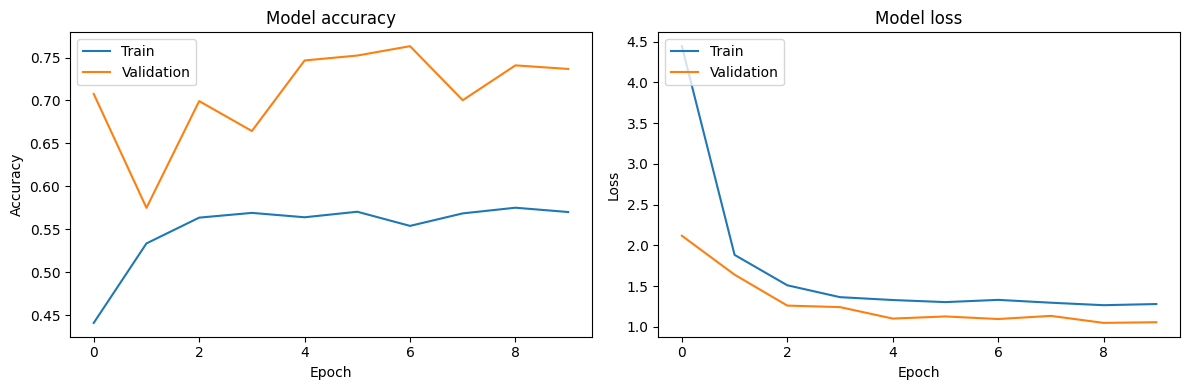

2026-01-11 17:20:39.692037: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.7328 - loss: 1.0794
Test accuracy: 0.7442, Test loss: 1.0495


2026-01-11 17:20:49.152878: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [12]:
evaluate_history(warmup_history)

# Fine Tuning

In [13]:
with strategy.scope():
    base_model.trainable = True
    for layer in base_model.layers[:-40]:
        layer.trainable = False
    
    model.compile(optimizer=Adam(learning_rate=2e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])


tuned_history = model.fit(train_dataset, 
                    epochs=EPOCHS,
                    validation_data=val_dataset,
                    callbacks=CALL_BACKS,
                    class_weight=class_weight_dict)

Epoch 1/40
INFO:tensorflow:Collective all_reduce tensors: 40 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1768152071.773599      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb1_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


94/94 ━━━━━━━━━━━━━━━━━━━━ 56s 377ms/step - accuracy: 0.4673 - loss: 1.4273 - val_accuracy: 0.6587 - val_loss: 1.0975 - learning_rate: 2.0000e-05
Epoch 2/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 312ms/step - accuracy: 0.6131 - loss: 1.2051 - val_accuracy: 0.7123 - val_loss: 1.0065 - learning_rate: 2.0000e-05
Epoch 3/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 317ms/step - accuracy: 0.6462 - loss: 1.0966 - val_accuracy: 0.7336 - val_loss: 0.9492 - learning_rate: 2.0000e-05
Epoch 4/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 319ms/step - accuracy: 0.6701 - loss: 1.0212 - val_accuracy: 0.7664 - val_loss: 0.9038 - learning_rate: 2.0000e-05
Epoch 5/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 315ms/step - accuracy: 0.6901 - loss: 0.9619 - val_accuracy: 0.7659 - val_loss: 0.8707 - learning_rate: 2.0000e-05
Epoch 6/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 315ms/step - accuracy: 0.7003 - loss: 0.9416 - val_accuracy: 0.7695 - val_loss: 0.8459 - learning_rate: 2.0000e-05
Epoch 7/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 316ms/step - accuracy: 0.71

# Final results

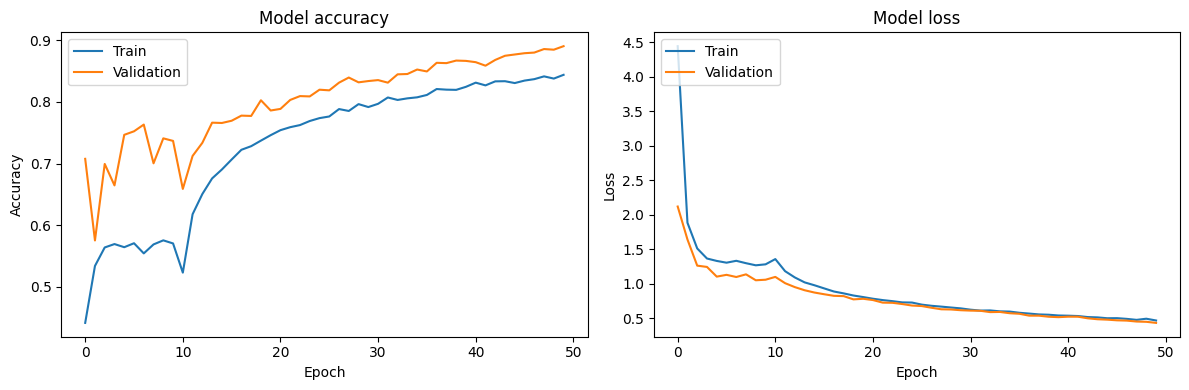

2026-01-11 17:42:10.234566: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.8908 - loss: 0.4561
Test accuracy: 0.8873, Test loss: 0.4526


2026-01-11 17:42:18.610952: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [14]:
evaluate_histories(warmup_history, tuned_history)

# Downloading the final model

In [15]:
model.save('model.keras')
print("✓ Model saved as model.keras")

model_info = {
    'img_size': 224,
    'num_classes': 6,
    'class_names': ['safe_driving', 'texting_right', 'talking_right', 
                    'texting_left', 'talking_left', 'drinking'],
    'architecture': 'EfficientNetB1',
    'input_shape': [224, 224, 3],
    'preprocessing': 'efficientnet_preprocess_input'
}

with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print("✓ Model info saved")

from IPython.display import FileLink
FileLink('model.keras')
FileLink('model_info.json')

✓ Model saved as model.keras
✓ Model info saved


/kaggle/working/model_info.json